In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import os
import sys
from pathlib import Path

# Проверяем, запускался ли уже этот блок
if "IS_ROOT_SET" not in globals():
    project_root = Path.cwd().parent.parent
    os.chdir(project_root)

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    # Создаем флаг-индикатор
    IS_ROOT_SET = True
    print("Корневая директория инициализирована.")
else:
    print("Инициализация уже была выполнена ранее.")

Инициализация уже была выполнена ранее.


In [11]:
import json
import os
from pathlib import Path

import cv2
from pydantic import ValidationError

In [12]:
from src.schemas.coco_dataset import COCODataset, COCOCategory, COCOImageResponse

In [13]:
dataset_dir = Path("datasets/minecraft")

Функция проверки валидности COCO структуры датасета

In [14]:
def check_annotation_structure(path: Path) -> bool:
    with open(path, mode="r") as file:
        data = json.load(file)
        try:
            COCODataset(**data)
            return True
        except Exception as e:
            raise e

Проверка корректности картинок и предоставленных аннотаций

In [15]:
def check_annotations_and_images(data_dir: Path) -> bool:
    image_extensions = (
        ".jpg",
        ".jpeg",
        ".png",
        ".webp",
        ".gif",
        ".svg",
        ".bmp",
        ".tiff",
        ".heic",
        ".avif",
    )

    annotations_path = data_dir / "annotations.json"
    if not annotations_path.is_file():
        raise FileNotFoundError(f"Файл аннотаций не найден по пути: {annotations_path}")

    valid_images = set()
    for f in os.listdir(data_dir):
        if f.lower().endswith(image_extensions):
            full_path = data_dir / f

            img = cv2.imread(str(full_path))
            if img is not None:
                valid_images.add(f)
            else:
                print(f"⚠️ Файл поврежден или не читается: {f}")

    with open(annotations_path, mode="r", encoding="utf-8") as f:
        data = json.load(f)

    annotated_images = set(
        [img_info["file_name"] for img_info in data.get("images", [])]
    )

    diff_images_minus_ann = valid_images - annotated_images
    diff_ann_minus_images = annotated_images - valid_images

    if diff_images_minus_ann or diff_ann_minus_images:
        if diff_images_minus_ann:
            print(
                "Картинки есть на диске, но отсутствуют в JSON (Images - Annotations):"
            )
            print(diff_images_minus_ann)
            print("-" * 30)
        if diff_ann_minus_images:
            print(
                "Картинки заявлены в JSON, но физически отсутствуют на диске/повреждены (Annotations - Images):"
            )
            print(diff_ann_minus_images)
            print("-" * 30)
        return False
    else:
        print("✅ Все файлы и аннотации идеально совпадают!")
        return True


In [16]:
dirs = ["train", "valid", "test"]

for dir in dirs:
    print(f"Проверка аннотаций в {dir}")
    try:
        checked = check_annotation_structure(dataset_dir / dir / "annotations.json")
    except ValidationError as e:
        print("❌ ОШИБКА ВАЛИДАЦИИ СТРУКТУРЫ COCO!")
        print(f"Всего обнаружено нестыковок: {e.error_count()}\n")
        print("--- ТОП-5 ПРОБЛЕМНЫХ МЕСТ В ДАННЫХ ---")

        for i, error in enumerate(e.errors()[:5]):
            path_to_error = " -> ".join(str(loc) for loc in error["loc"])
            error_type = error["type"]
            error_msg = error["msg"]

            bad_value = error.get("input", "Не удалось определить")

            print(f"Ошибка #{i + 1}:")
            print(f"  📍 Где искать: {path_to_error}")
            print(f"  📝 Что не так: {error_msg} (тип ошибки: {error_type})")
            print(f"  ❌ Что там записано сейчас: {bad_value}")
            print("-" * 40)
    print(f"Проверено {dir}")
print("Все ок!")

Проверка аннотаций в train
Проверено train
Проверка аннотаций в valid
Проверено valid
Проверка аннотаций в test
Проверено test
Все ок!


In [17]:
for dir in dirs:
    print(f"Проверка {dir}")
    check_annotations_and_images(dataset_dir / dir)

Проверка train
✅ Все файлы и аннотации идеально совпадают!
Проверка valid
✅ Все файлы и аннотации идеально совпадают!
Проверка test
✅ Все файлы и аннотации идеально совпадают!


In [18]:
train_dataset = COCODataset.load(path=dataset_dir / "train")
valid_dataset = COCODataset.load(path=dataset_dir / "valid")
test_dataset = COCODataset.load(path=dataset_dir / "test")

Анализ распределений классов

In [19]:
from collections import Counter
import pandas as pd

In [20]:
def caclualcte_categories_distibutions(dataset: COCODataset):
    category_map = {cat.id: cat.name for cat in dataset.categories}

    counts = Counter(ann.category_id for ann in dataset.annotations)

    data = []
    for cat_id, count in counts.items():
        class_name = category_map.get(cat_id, "Unknown")
        data.append({"class_name": class_name, "count": count})

    df = pd.DataFrame(data).sort_values("count", ascending=False)
    return df

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt


def vizualize_category_distibutions(data: pd.DataFrame, name: str) -> None:
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, min(5, max(4, len(data) * 0.2))))

    ax = sns.barplot(
        data=data,
        x="count",
        y="class_name",
        palette="viridis",
        hue="class_name",
        legend=False,
    )

    plt.title(f"Распределение классов в датасете. Датасет {name}", fontsize=14, pad=15)
    plt.xlabel("Количество аннотаций")
    plt.ylabel("Название класса")
    plt.tight_layout()
    plt.show()

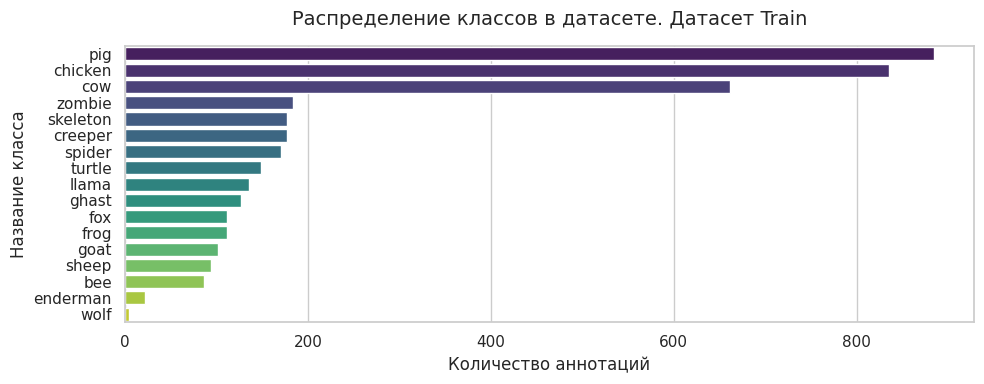

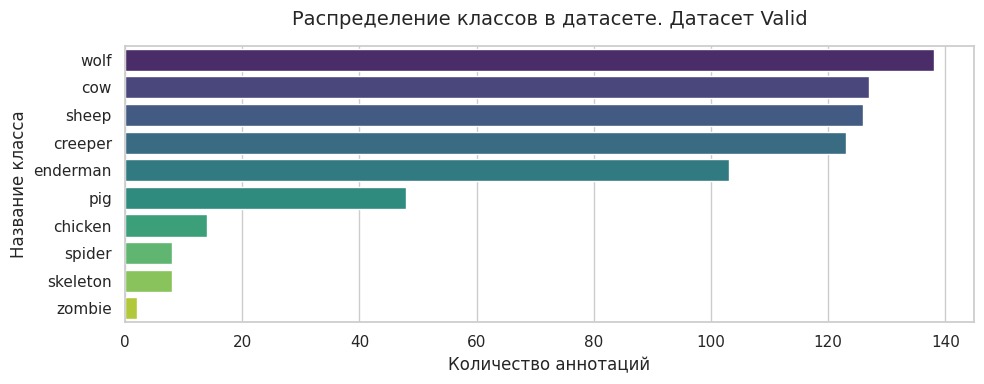

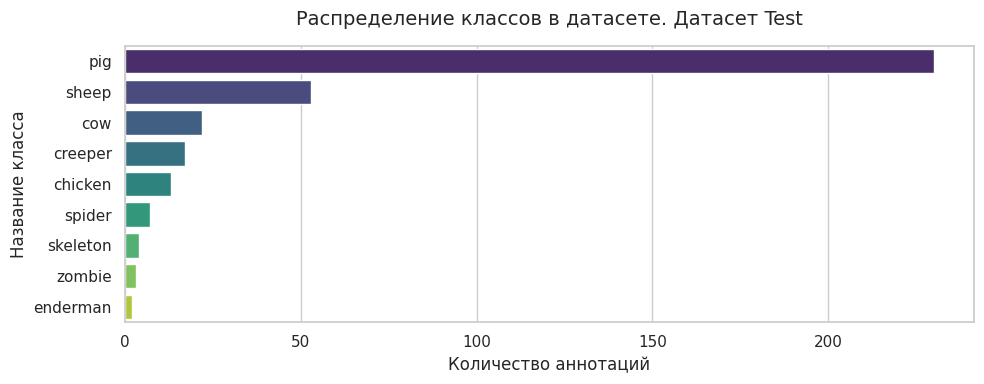

In [22]:
datasets = [train_dataset, valid_dataset, test_dataset]
names = ["Train", "Valid", "Test"]

for dataset, name in zip(datasets, names):
    data_count = caclualcte_categories_distibutions(dataset=dataset)
    vizualize_category_distibutions(data_count, name)

Из наблюдений, видно, что в валидационном датасете преобладает класс wolf, который был почти не аннотирован в train выборке.

Отрисуем один тестовый пример

In [23]:
import random

In [24]:
random_image = random.choice(test_dataset.images)
example = test_dataset.get_data_by_image_id(random_image.id)

In [25]:
def get_dataset_color_map(
    categories: list[COCOCategory],
) -> dict[int, tuple[int, int, int]]:
    cat_ids = sorted([cat.id for cat in categories])
    num_classes = len(cat_ids)

    sns_colors = sns.color_palette("tab20", num_classes)

    color_map = {}
    for i, cat_id in enumerate(cat_ids):
        r, g, b = sns_colors[i]
        bgr_color = (int(b * 255), int(g * 255), int(r * 255))
        color_map[cat_id] = bgr_color

    return color_map


categories = test_dataset.categories
color_map = get_dataset_color_map(categories=categories)

In [26]:
def draw_bounding_boxes(
    image_path: Path,
    bboxes: tuple[list[float]],
    labels: tuple[str],
    colors: tuple[int, int, int],
) -> None:

    if not image_path.exists():
        FileNotFoundError(f"Файл не найден: {image_path}")

    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Это не картинка")

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1

    for bbox, label, color in zip(bboxes, labels, colors):
        x, y, w, h = bbox
        (text_width, text_height), _ = cv2.getTextSize(label, font, font_scale, 1)

        pt1 = (int(x), int(y))
        pt2 = (int(x + w), int(y + h))

        cv2.rectangle(image, pt1, pt2, color, thickness=1)

        cv2.rectangle(
            image,
            (int(x), int(y - text_height - 2)),
            (int(x + text_width + 2), int(y)),
            color,
            thickness=cv2.FILLED,
        )
        cv2.putText(
            image,
            label,
            (int(x), int(y - 4)),
            cv2.FONT_ITALIC,
            font_scale,
            (0, 0, 0),
            1,
        )

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [27]:
id2label = {cat.id: cat.name for cat in train_dataset.categories}

In [28]:
from src.constants import MINECRAFT_CLASS_COLORS_RGB, DEFAULT_COLOR_BGR

In [29]:
def draw_image(data: COCOImageResponse) -> None:
    image_path = test_dataset.get_image_path(image_id=data.image.id)
    bboxes = [annot.bbox for annot in data.annotations]
    category_ids = [annot.category_id for annot in data.annotations]
    labels = [id2label[idx] for idx in category_ids]
    colors = [
        MINECRAFT_CLASS_COLORS_RGB.get(label, DEFAULT_COLOR_BGR) for label in labels
    ]

    draw_bounding_boxes(
        image_path=image_path, bboxes=bboxes, labels=labels, colors=colors
    )

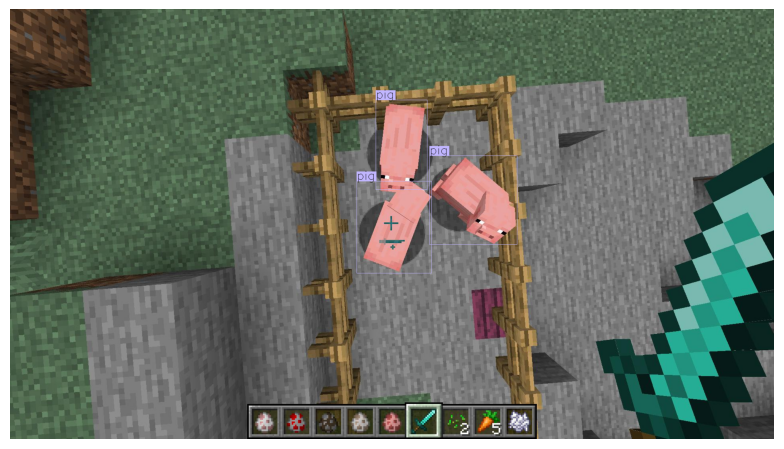

In [30]:
draw_image(example)